In [4]:
import numpy as np
import ssm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [5]:
def firing_by_angle_bin(angles, neural_activity, nbins):
    angles_firing = np.zeros(nbins - 1)
    angles_std = np.zeros(nbins - 1)
    unique_groups, group_counts = np.unique(angles, return_counts=True)
    # mean firing
    group_sums = np.bincount(angles, weights=neural_activity)
    angles_firing[unique_groups] = group_sums[unique_groups] / group_counts
    # std of firing
    group_sums_squared = np.bincount(angles, weights=neural_activity**2)
    mean_squared = angles_firing[unique_groups] ** 2
    variance = (group_sums_squared[unique_groups] / group_counts) - mean_squared
    angles_std[unique_groups] = np.sqrt(variance)
    return angles_firing, angles_std

Text(0.5, 1.0, "firing by category \nin the two states ('-', '--')")

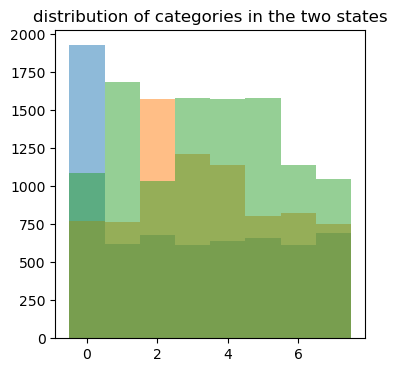

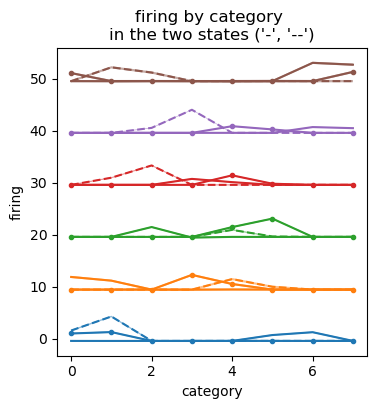

In [57]:
'''Generate synthetic data'''
time = 25000
# states
states = [0,1,2] # what are our states
start_prob = [.7,.1,.2] # probability we start with one state
# transition_matrix = [[0.9, 0.05, 0.05], [0.05, 0.9, 0.05], [0.05, 0.05, 0.9]] # transition probability between states
transition_matrix = [[0.8, 0.1, 0.1], [0.1, 0.85, 0.05], [0.05, 0.05, 0.9]] # transition probability between states
all_state = np.zeros((time,),dtype = int)
all_state[0] = np.random.choice(states,p=start_prob)
for t in range(1,time):
    trans = transition_matrix[all_state[t-1]]
    all_state[t] = np.random.choice(states,p=trans)

# data
obs_cat = 8
# don't sample observations uniformaly, this mkaes states more distinguishable
state_obs_probs = {
    0: [0.3, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    1: [0.1, 0.1, 0.2, 0.15, 0.15, 0.1, 0.1, 0.1],
    2: [0.1, 0.15, 0.1, 0.15, 0.15, 0.15, 0.1, 0.1]
}
obs = np.zeros_like(all_state)
for i in states:
    t_in_state = np.sum(all_state == i)
    # uniformly assign time in each state to each category of obs
    # obs[all_state == i] = np.random.randint(obs_cat,size = t_in_state) 
    obs[all_state == i] = np.random.choice(np.arange(obs_cat), p=state_obs_probs[i], size=np.sum(all_state == i))

colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axs = plt.subplots(1,1,figsize = (4,4))
for i in np.unique(all_state):
    axs.hist(obs[all_state == i], bins = np.arange(obs_cat+1) - .5, alpha = .5, color = colorz[i])
axs.set_title("distribution of categories in the two states")

# inputs
n_inpt = 6
inputs = np.zeros((time,n_inpt))
idx = np.arange(n_inpt)
case = 'different' # 'rotation', 'noise
if case == "different":
    for j in np.arange(n_inpt):
        for i in states:
            o = obs[all_state == i]
            new_inpt = np.ones(obs_cat)
            new_inpt[int(obs_cat/2):int(obs_cat/2)+2] = [np.random.randint(5,10),np.random.randint(5,10)*np.abs(np.random.normal(1))]
            w = np.roll(new_inpt,np.random.randint(obs_cat))
            inputs[all_state == i,j] = w[o]
            # add noise to make the input-output mapping less deterministic
            inputs[all_state == i, j] += np.random.normal(0, 0.5, size=np.sum(all_state == i))
if case == "roll":
    for j in np.arange(n_inpt):
        new_inpt = np.ones(obs_cat)
        where = np.random.randint(obs_cat)
        height = np.random.randint(20)
        new_inpt[where] = height
        new_inpt[where+1] = height*np.abs(np.random.normal(1))
        shifts = np.random.choice(np.arange(1,obs_cat), size = len(states), replace = False)
        for i in states:
            o = obs[all_state == i]
            w = np.roll(np.array(new_inpt), shifts[i])
            inputs[all_state == i,j] = w[o]
            # add noise to make the input-output mapping less deterministic
            inputs[all_state == i, j] += np.random.normal(0, 0.5, size=np.sum(all_state == i))

# scale and standardize inputs
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
inputs = scaler.fit_transform(inputs)

# one-hot encode observations (creates binary indicator variables for each observation category, potentially improving the GLM weight fitting.)
# unfortunately obs needs to be 1D
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse=False)
obs_onehot = encoder.fit_transform(obs.reshape(-1, 1))

"""How do the tuning curves look like across states"""
fig,ax = plt.subplots(n_inpt,1,figsize = (8,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
linetype = ['-','--','.-']
for idx in np.arange(n_inpt):
    for i in np.unique(all_state):
        i = int(i)
        y, error = firing_by_angle_bin(obs[all_state == i],inputs[all_state == i,idx], obs_cat+1)
        ax[idx].fill_between(np.arange(obs_cat), y-error, y+error, alpha=.5, facecolor = colorz[idx], linewidth=0)
        ax[idx].plot(np.arange(obs_cat),y, linetype[i], color = colorz[idx])
ax.set_xlabel("category")
ax.set_ylabel("firing")
ax.set_title("firing by category \nin the two states ('-', '--')")
plt.tight_layout()

In [74]:
num_states = 1
obs_dim = 1 # hdir
input_dim = np.shape(inputs)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 200
prior_sigma = 100 # needs a grid search! default = 1000
prior_mean = 1 # default is 0

# initiate the HMM
glm = ssm.HMM(num_states, 
                  obs_dim, 
                  input_dim, 
                  observations="input_driven_obs", # maybe this allows to pass a categorical observation?!
                  observation_kwargs=dict(C=num_categories, prior_sigma = prior_sigma, prior_mean = prior_mean),
                  transitions="standard") 

# fit the HMM
ll_glm = glm.fit([np.array([[o] for o in obs])], inputs=[inputs], method="em", num_iters=N_iters)

  0%|          | 0/200 [00:00<?, ?it/s]

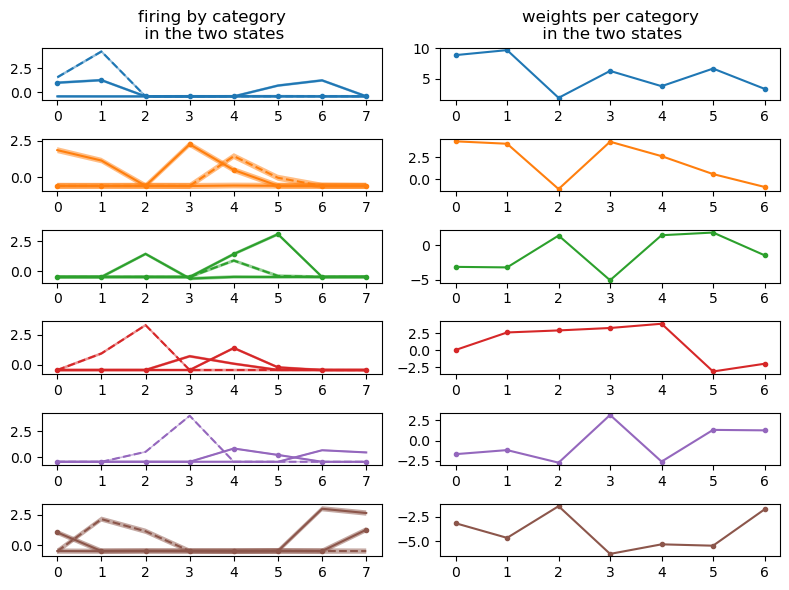

In [75]:
recovered_weights = glm.observations.Wk

# Initialize observation weights as GLM weights with some noise:
glm_vectors_repeated = np.tile(recovered_weights, (len(states), 1, 1))
glm_vectors_with_noise = glm_vectors_repeated + np.random.normal(
    0, 1, glm_vectors_repeated.shape)

"""How do the tuning curves compare to the GLM weights?"""
fig,ax = plt.subplots(n_inpt,2,figsize = (8,6))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
linetype = ['-','--','.-']
for idx in np.arange(n_inpt):
    for i in states:
        i = int(i)
        y, error = firing_by_angle_bin(obs[all_state == i],inputs[all_state == i,idx], obs_cat+1)
        ax[idx,0].fill_between(np.arange(obs_cat), y-error, y+error, alpha=.5, facecolor = colorz[idx], linewidth=0)
        ax[idx,0].plot(np.arange(obs_cat),y, linetype[i], color = colorz[idx])
    ax[idx,1].plot(recovered_weights[0,:,idx], linetype[i], color = colorz[idx])
    # shift += 10
ax[0,0].set_title("firing by category\n in the two states")
ax[0,1].set_title("weights per category\n in the two states")        
plt.tight_layout()

In [81]:
"""Try to fit a GLM-HMM"""
num_states = len(states) # by design
obs_dim = 1 # hdir
input_dim = np.shape(inputs)[1] # n_neurons
num_categories = len(np.unique(obs)) # n_bins of hdir
N_iters = 200
prior_sigma = 100 # needs a grid search! default = 1000
prior_mean = 1 # default is 0

# initiate the HMM
glm_hmm = ssm.HMM(num_states, 
                  obs_dim, 
                  input_dim, 
                  observations="input_driven_obs", # maybe this allows to pass a categorical observation?!
                  observation_kwargs=dict(C=num_categories, prior_sigma = prior_sigma, prior_mean = prior_mean),
                  transitions="standard") 
glm_hmm.observations.params = glm_vectors_with_noise

# fit the HMM
ll = glm_hmm.fit([np.array([[o] for o in obs])], inputs=[inputs], method="em", num_iters=N_iters)#, tolerance=10**-4)

  0%|          | 0/200 [00:00<?, ?it/s]

In [83]:
"""How well did it guess the transition matrix?"""
t = [list(x) for x in glm_hmm.transitions.transition_matrix]
print('predicted transitions matrix are: ' + str(t) + '\n input transition matrix are: ' + str(transition_matrix))

predicted transitions matrix are: [[0.8901520788985512, 0.04911279714956019, 0.060735123951888646], [0.03958363845793528, 0.8330748181076507, 0.12734154343441403], [0.27530031712567427, 0.41863544680579956, 0.30606423606852606]]
 input transition matrix are: [[0.8, 0.1, 0.1], [0.1, 0.85, 0.05], [0.05, 0.05, 0.9]]


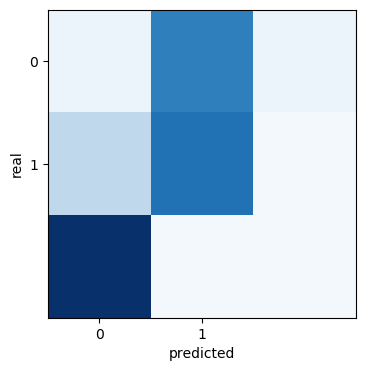

In [84]:
"""How well did it guess the state at each time?"""
state_pred = glm_hmm.most_likely_states(np.array([[o] for o in obs]), input=inputs)

conf = confusion_matrix(all_state, state_pred)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs.set_ylabel("real")
axs.set_xlabel("predicted")
axs.set_xticks([0,1])
axs.set_yticks([0,1])
title = []
for st in states:
    title.append('% time in state 0, real: ' + "%.2f" % (np.sum(all_state == st)/len(all_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == st)/len(state_pred)) + '\n')
# axs.set_title('% time in state 0, real: ' + "%.2f" % (np.sum(all_state == 0)/len(all_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 0)/len(state_pred)) +
#               '\n% time in state 1, real: ' + "%.2f" % (np.sum(all_state == 1)/len(all_state)) +' , predicted: ' + "%.2f" % (np.sum(state_pred == 1)/len(state_pred)))

Text(0.5, 1.0, "'--' for predicted, '-' for real")

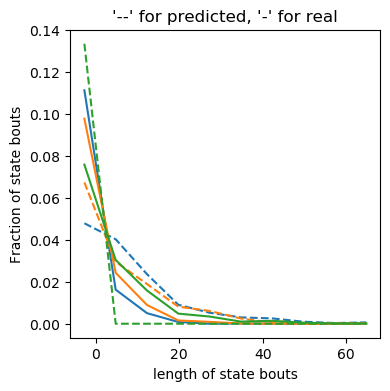

In [85]:
"""How long does each state bout last?"""

real_time = []
for i in states:
    st = (all_state == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    real_time.append(np.abs(start - end))

pred_time = []
for i in states:
    st = (state_pred == i).astype(int)
    if st[0] == 1:
        st = np.hstack((np.zeros(1),st))
    if st[-1] == 1:
        st = np.hstack((st,np.zeros(1)))
    start = np.where(np.diff(st) == 1)[0]
    end = np.where(np.diff(st) == -1)[0]
    pred_time.append(np.abs(start - end))

longest = np.amax(np.append(np.concatenate(pred_time), np.concatenate(real_time)))
shortest = np.amin(np.append(np.concatenate(pred_time), np.concatenate(real_time)))

fig, axs = plt.subplots(1,1,figsize = (4,4))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in states:
    # real
    h, b = np.histogram(real_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '-', color = colorz[i])
    # pred
    h, b = np.histogram(pred_time[i],range = (shortest,longest), density = True)
    bc = b[:-1]-np.mean(np.diff(b))/2
    axs.plot(bc,h, '--', color = colorz[i])

axs.set_xlabel('length of state bouts')
axs.set_ylabel('Fraction of state bouts')
axs.set_title("'--' for predicted, '-' for real")

In [86]:
"""Predict the angles based on the neural activty and the expected states"""
data = np.zeros((len(obs),) + (1,), dtype=int)
pred_angles = np.zeros(len(obs))
for i in np.arange(len(obs)):
    pred_angles[i] = glm_hmm.observations.sample_x(z = state_pred[i], xhist = data[:i], input=inputs[i])
pred_latents = state_pred

Text(0.5, 0, 'binned angles')

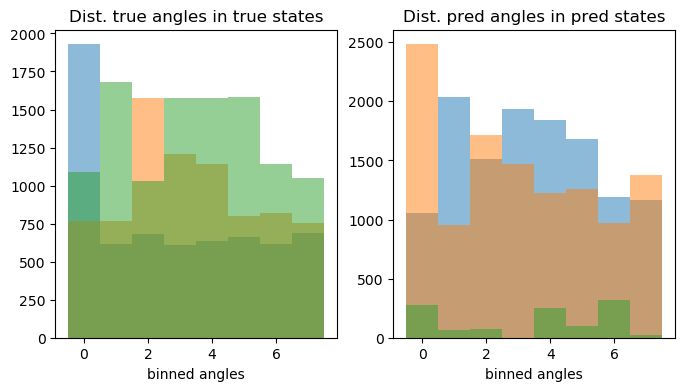

In [87]:
"""Distribution of angles in the two states"""
# pred_latents, pred_angles = glm_hmm.sample(len(obs), input=inputs)
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axs = plt.subplots(1,2,figsize = (8,4))
for i in np.unique(all_state):
    axs[0].hist(obs[all_state == i], bins = np.arange(obs_cat+1) - .5, alpha = .5, color = colorz[i])
axs[0].set_title('Dist. true angles in true states')
axs[0].set_xlabel('binned angles')

for i in np.unique(pred_latents):
    axs[1].hist(pred_angles[pred_latents == i], bins = np.arange(obs_cat+1) - .5, alpha = .5, color = colorz[i])
axs[1].set_title('Dist. pred angles in pred states')
axs[1].set_xlabel('binned angles')

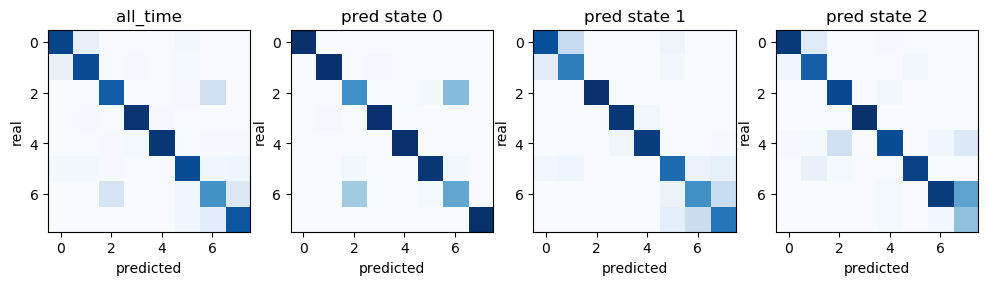

In [88]:
"""Based on the inputs, what does it think the angles should be?"""
conf = confusion_matrix(obs, pred_angles)
conf = conf.astype("float64")
conf = conf / np.sum(conf, axis=1)

fig, axs = plt.subplots(1,len(states)+1,figsize = (12,4))
axs[0].imshow(conf, cmap="Blues", vmin=0, vmax=1)
axs[0].set_ylabel("real")
axs[0].set_xlabel("predicted")
axs[0].set_title("all_time")

for st in states:
    conf = confusion_matrix(obs[pred_latents == st], pred_angles[pred_latents == st])
    conf = conf.astype("float64")
    conf = conf / np.sum(conf, axis=1)
    axs[st+1].imshow(conf, cmap="Blues", vmin=0, vmax=1)
    axs[st+1].set_ylabel("real")
    axs[st+1].set_xlabel("predicted")
    axs[st+1].set_title("pred state " + str(st))

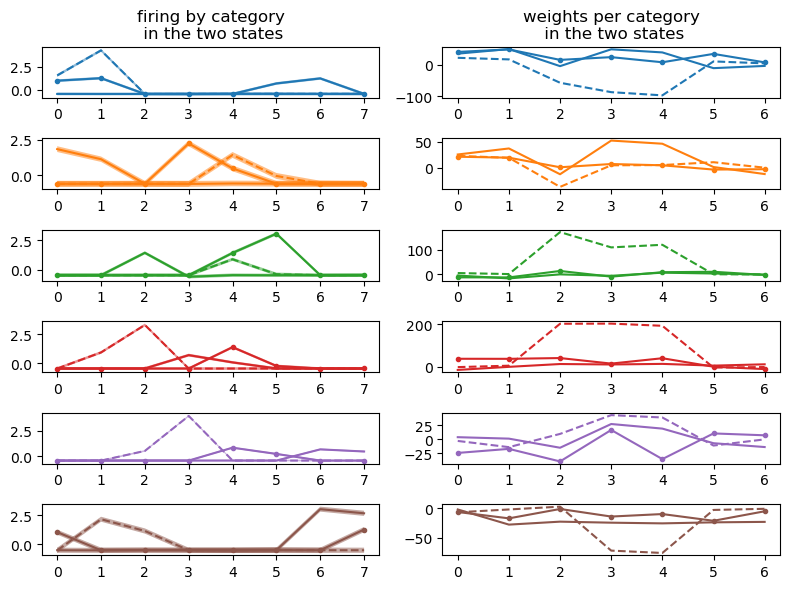

In [89]:
"""How do the tuning curves compare to the weights?"""
fig,ax = plt.subplots(n_inpt,2,figsize = (8,6))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
linetype = ['-','--','.-']
for idx in np.arange(n_inpt):
    for i in states:
        i = int(i)
        y, error = firing_by_angle_bin(obs[all_state == i],inputs[all_state == i,idx], obs_cat+1)
        ax[idx,0].fill_between(np.arange(obs_cat), y-error, y+error, alpha=.5, facecolor = colorz[idx], linewidth=0)
        ax[idx,0].plot(np.arange(obs_cat),y, linetype[i], color = colorz[idx])
        ax[idx,1].plot(glm_hmm.observations.Wk[i,:,idx], linetype[i], color = colorz[idx])
    # shift += 10
ax[0,0].set_title("firing by category\n in the two states")
ax[0,1].set_title("weights per category\n in the two states")        
plt.tight_layout()

In [ ]:
"""Fit a GLM to all the data first, to then initialize the weights in the glm_hmm"""
#TODO: this is buggy
from ssm.optimizers import adam, bfgs, rmsprop, sgd
import autograd.numpy.random as npr
from autograd.scipy.special import logsumexp
from ssm.util import ensure_args_are_lists
import ssm.stats as stats

class glm(object):
    def __init__(self, M, C):
        """
        @param C:  number of classes in the categorical observations
        """
        self.M = M
        self.C = C
        # Parameters linking input to state distribution
        self.Wk = npr.randn(1, C - 1, M + 1)

    @property
    def params(self):
        return self.Wk

    @params.setter
    def params(self, value):
        self.Wk = value

    def log_prior(self):
        return 0

    # Calculate time dependent logits - output is matrix of size Tx1xC
    # Input is size TxM
    def calculate_logits(self, input):
        # Update input to include offset term:
        input = np.append(input, np.ones((input.shape[0], 1)), axis=1)
        # Add additional row (of zeros) to second dimension of self.Wk
        Wk_tranpose = np.transpose(self.Wk, (1, 0, 2))
        Wk = np.transpose(
            np.vstack([
                Wk_tranpose,
                np.zeros((1, Wk_tranpose.shape[1], Wk_tranpose.shape[2]))
            ]), (1, 0, 2))
        # Input effect; transpose so that output has dims TxKxC
        time_dependent_logits = np.transpose(np.dot(Wk, input.T), (2, 0, 1))
        time_dependent_logits = time_dependent_logits - logsumexp(
            time_dependent_logits, axis=2, keepdims=True)
        return time_dependent_logits

    # Calculate log-likelihood of observed data
    def log_likelihoods(self, data, input, mask, tag):
        time_dependent_logits = self.calculate_logits(input)
        mask = np.ones_like(data, dtype=bool) if mask is None else mask
        return stats.categorical_logpdf(data[:, None, :],
                                        time_dependent_logits[:, :, None, :],
                                        mask=mask[:, None, :])
        
    # log marginal likelihood of data
    @ensure_args_are_lists
    def log_marginal(self, datas, inputs, masks, tags):
        elbo = self.log_prior()
        for data, input, mask, tag in zip(datas, inputs, masks, tags):
            lls = self.log_likelihoods(data, input, mask, tag)
            elbo += np.sum(lls)
        return elbo
    
    @ensure_args_are_lists
    def fit_glm(self, datas, inputs, masks, tags, num_iters=1000, optimizer="bfgs", **kwargs):
        optimizer = dict(adam=adam, bfgs=bfgs, rmsprop=rmsprop,
                         sgd=sgd)[optimizer]

        def _objective(params, itr):
            self.params = params
            obj = self.log_marginal(datas, inputs, masks, tags)
            return -obj

        self.params = optimizer(_objective,
                                self.params,
                                num_iters=num_iters,
                                **kwargs)

new_glm = glm(n_inpt, obs_cat)
new_glm.fit_glm(inputs = [inputs], datas = [np.array([[o] for o in obs])], masks=None, tags=None)
# Get loglikelihood of training data:
recovered_weights = new_glm.Wk

# Initialize observation weights as GLM weights with some noise:
glm_vectors_repeated = np.tile(recovered_weights, (len(states), 1, 1))
glm_vectors_with_noise = glm_vectors_repeated + np.random.normal(
    0, 0.2, glm_vectors_repeated.shape)

"""How do the tuning curves compare to the GLM weights?"""
fig,ax = plt.subplots(n_inpt,2,figsize = (8,6))
colorz = plt.rcParams['axes.prop_cycle'].by_key()['color']
linetype = ['-','--','.-']
for idx in np.arange(n_inpt):
    for i in states:
        i = int(i)
        y, error = firing_by_angle_bin(obs[all_state == i],inputs[all_state == i,idx], obs_cat+1)
        ax[idx,0].fill_between(np.arange(obs_cat), y-error, y+error, alpha=.5, facecolor = colorz[idx], linewidth=0)
        ax[idx,0].plot(np.arange(obs_cat),y, linetype[i], color = colorz[idx])
    ax[idx,1].plot(recovered_weights[:,idx], linetype[i], color = colorz[idx])
    # shift += 10
ax[0,0].set_title("firing by category\n in the two states")
ax[0,1].set_title("weights per category\n in the two states")        
plt.tight_layout()